## Projection des données ERA5 sur la zone Ouest Africaine des précipitations 

In [2]:
## chargement de la data initiale
import pandas as pd
import numpy as np
#import seaborn as sns
import matplotlib.pyplot as plt
dataset = pd.read_csv("Dataset.csv")
print(dataset.shape)

(26040168, 11)


In [3]:
# Nouvel ordre
dataset = dataset[['time', 'latitude', 'longitude','Temp_2m','SST','Total_precip','level','Rel_hum','Spec_hum','U_wind','V_wind']]


In [6]:
dataset=dataset.set_index(['time','latitude', 'longitude'])
dataset

KeyError: "None of ['time'] are in the columns"

In [5]:
# ordonner le dataset
dataset = dataset.sort_index()
# remplacer les données manquantes par 0
dataset= dataset.fillna(0)

In [6]:
dataset

Temp_2m        SST  Total_precip  \
time                longitude latitude                                       
2020-06-01 00:00:00 -19.75    7.25      300.25520  302.23798      0.000282   
                              16.75     294.47174  295.83865      0.000000   
                    -19.50    9.00      299.81763  301.64435      0.000124   
                              10.25     299.32330  300.99188      0.000000   
                    -19.25    12.50     297.28653  298.93726      0.000000   
...                                           ...        ...           ...   
2020-11-30 23:00:00  8.25     10.00     292.77536    0.00000      0.000000   
                     8.50     17.00     295.19974    0.00000      0.000000   
                     9.00     5.00      296.90848    0.00000      0.000000   
                     9.50     15.75     292.73828    0.00000      0.000000   
                     9.75     9.50      292.98490    0.00000      0.000000   

                                        level    Rel_hum  Spec_hum     U_wind  \
time                longitude latitude                                          
2020-06-01 00:00:00 -19.75    7.25        825  22.914597  0.004155  -6.126280   
                              16.75       600  93.905000  0.006245  -0.005903   
                    -19.50    9.00        825  27.349700  0.004742  -6.396275   
                              10.25      1000  93.150150  0.016053  -3.875356   
                    -19.25    12.50       700  86.178830  0.008801  -9.536596   
...                                       ...        ...       ...        ...   
2020-11-30 23:00:00  8.25     10.00       700  65.262270  0.006939 -13.026322   
                     8.50     17.00       100  59.711860  0.000003  23.412949   
                     9.00     5.00        600  62.540610  0.004489  -8.479715   
                     9.50     15.75       700  77.266830  0.007918 -12.920924   
                     9.75     9.50       1000  77.689964  0.016467  -1.124868   

                                          V_wind  
time                longitude latitude            
2020-06-01 00:00:00 -19.75    7.25     -4.354439  
                              16.75     3.954667  
                    -19.50    9.00     -1.971410  
                              10.25    -5.491364  
                    -19.25    12.50    -2.393427  
...                                          ...  
2020-11-30 23:00:00  8.25     10.00     1.553792  
                     8.50     17.00     0.260448  
                     9.00     5.00      4.960368  
                     9.50     15.75     2.193116  
                     9.75     9.50     -1.006651  

[260402 rows x 8 columns]

In [7]:
df = dataset.loc['2020-08-15 08:00:00',:] 

In [25]:
df.shape

(5929, 8)

In [29]:
# Convert the DataFrame to an xarray Dataset
import xarray as xr
ds = xr.Dataset.from_dataframe(df)

print(ds)

<xarray.Dataset> Size: 381kB
Dimensions:       (latitude: 49, longitude: 121)
Coordinates:
  * latitude      (latitude) float64 392B 5.0 5.25 5.5 5.75 ... 16.5 16.75 17.0
  * longitude     (longitude) float64 968B -20.0 -19.75 -19.5 ... 9.5 9.75 10.0
Data variables:
    Temp_2m       (latitude, longitude) float64 47kB 298.2 298.2 ... 302.7 303.3
    SST           (latitude, longitude) float64 47kB 300.6 300.6 ... 0.0 0.0
    Total_precip  (latitude, longitude) float64 47kB 3.699e-05 1.45e-05 ... 0.0
    level         (latitude, longitude) int64 47kB 100 200 600 ... 825 1000 100
    Rel_hum       (latitude, longitude) float64 47kB 145.6 35.65 ... 83.33 97.57
    Spec_hum      (latitude, longitude) float64 47kB 3.844e-06 ... 4.193e-06
    U_wind        (latitude, longitude) float64 47kB -13.63 -9.22 ... -13.07
    V_wind        (latitude, longitude) float64 47kB -2.251 8.762 ... -2.322


In [9]:
print(ds['Total_precip'].dims)  # Doit renvoyer ('time', 'latitude', 'longitude')

('latitude', 'longitude')


In [25]:
ds

<xarray.Dataset> Size: 113kB
Dimensions:       (latitude: 33, longitude: 53)
Coordinates:
  * latitude      (latitude) float64 264B 5.0 5.5 5.75 6.25 ... 16.0 16.25 16.5
  * longitude     (longitude) float64 424B -7.0 -1.0 -14.5 ... 8.0 9.25 -18.75
Data variables:
    Temp_2m       (latitude, longitude) float64 14kB 297.7 298.8 ... nan 295.1
    SST           (latitude, longitude) float64 14kB 0.0 298.5 nan ... nan 295.5
    Total_precip  (latitude, longitude) float64 14kB 7.246e-07 ... 6.527e-06
    level         (latitude, longitude) float64 14kB 825.0 825.0 ... nan 200.0
    Rel_hum       (latitude, longitude) float64 14kB 90.67 91.18 ... nan 29.87
    Spec_hum      (latitude, longitude) float64 14kB 0.01206 ... 2.581e-05
    U_wind        (latitude, longitude) float64 14kB -0.673 -0.1387 ... -8.389
    V_wind        (latitude, longitude) float64 14kB 1.511 1.013 ... nan 1.05

In [28]:
ds["Total_precip"]

<xarray.DataArray 'Total_precip' (latitude: 49, longitude: 121)> Size: 47kB
array([[7.1803110e-05, 3.4088270e-05, 2.3208559e-05, ..., 0.0000000e+00,
        7.2456896e-07, 2.9001385e-06],
       [7.7605250e-05, 4.4241548e-05, 2.1032989e-05, ..., 0.0000000e+00,
        5.0757080e-06, 5.0757080e-06],
       [1.2619980e-04, 6.8176540e-05, 4.2790547e-05, ..., 0.0000000e+00,
        1.6681850e-05, 1.0879710e-05],
       ...,
       [1.5955418e-05, 2.9737130e-05, 3.9165840e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.3055280e-05, 1.3055280e-05, 1.0153279e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [3.6265700e-06, 2.1755695e-06, 3.6265700e-06, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], shape=(49, 121))
Coordinates:
  * latitude   (latitude) float64 392B 5.0 5.25 5.5 5.75 ... 16.5 16.75 17.0
  * longitude  (longitude) float64 968B -20.0 -19.75 -19.5 ... 9.5 9.75 10.0

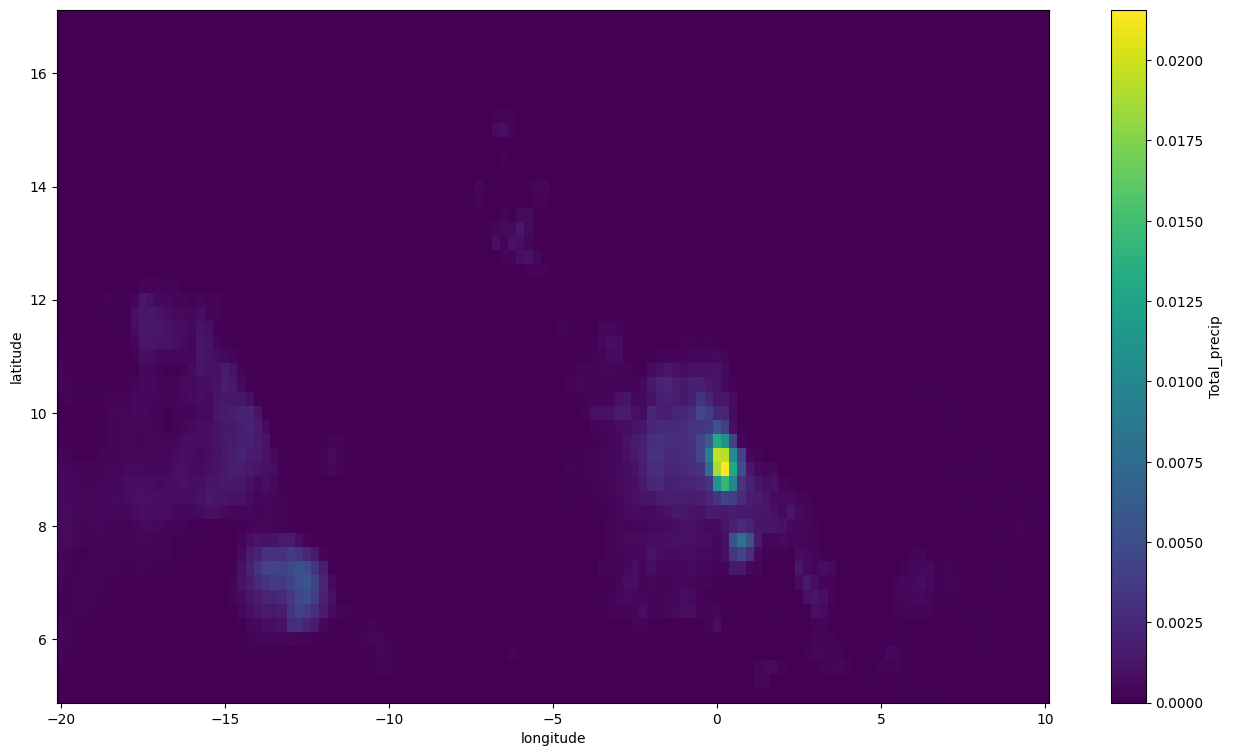

In [8]:
ds["Total_precip"].sortby(list(ds["Total_precip"].coords)).plot(figsize=(16, 9))
#ds["Total_precip"].sortby("time").plot(figsize=(16, 9))
#ds["Total_precip"].sortby("lat").plot(figsize=(16, 9))
#print(ds["Total_precip"].coords)


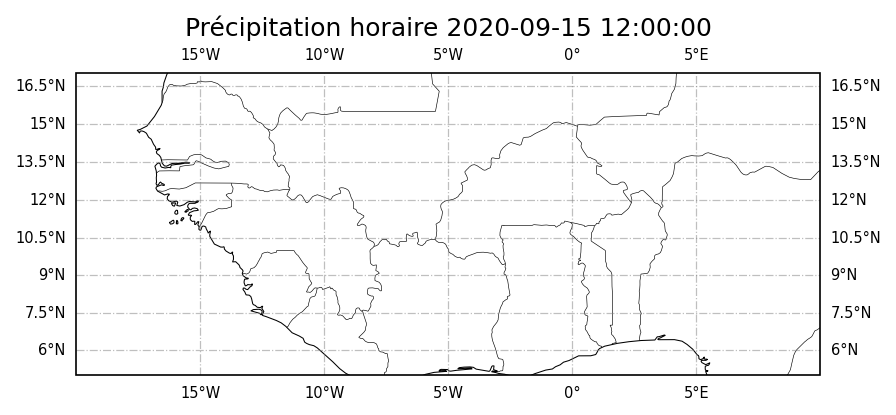

In [10]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# First we specify Coordinate Refference System for Map Projection
# We will use Mercator, which is a cylindrical, conformal projection. 
# It has bery large distortion at high latitudes, cannot 
# fully reach the polar regions.
projection = ccrs.Mercator()

# Specify CRS, that will be used to tell the code, where should our data be plotted
crs = ccrs.PlateCarree()

# Now we will create axes object having specific projection 
plt.figure(dpi=150)
ax = plt.axes(projection=projection, frameon=True)

# Draw gridlines in degrees over Mercator map
gl = ax.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.')
gl.xlabel_style = {"size" : 7}
gl.ylabel_style = {"size" : 7}

# To plot borders and coastlines, we can use cartopy feature
import cartopy.feature as cf
ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
ax.add_feature(cf.BORDERS.with_scale("50m"), lw=0.3)

# Now, we will specify extent of our map in minimum/maximum longitude/latitude
# Note that these values are specified in degrees of longitude and degrees of latitude
# However, we can specify them in any crs that we want, but we need to provide appropriate
# crs argument in ax.set_extent
lon_min = -20
lon_max = 10
lat_min = 5
lat_max = 17

# crs is PlateCarree -> we are explicitly telling axes, that we are creating bounds that are in degrees
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)
plt.title("Précipitation horaire 2020-09-15 12:00:00")
plt.show()

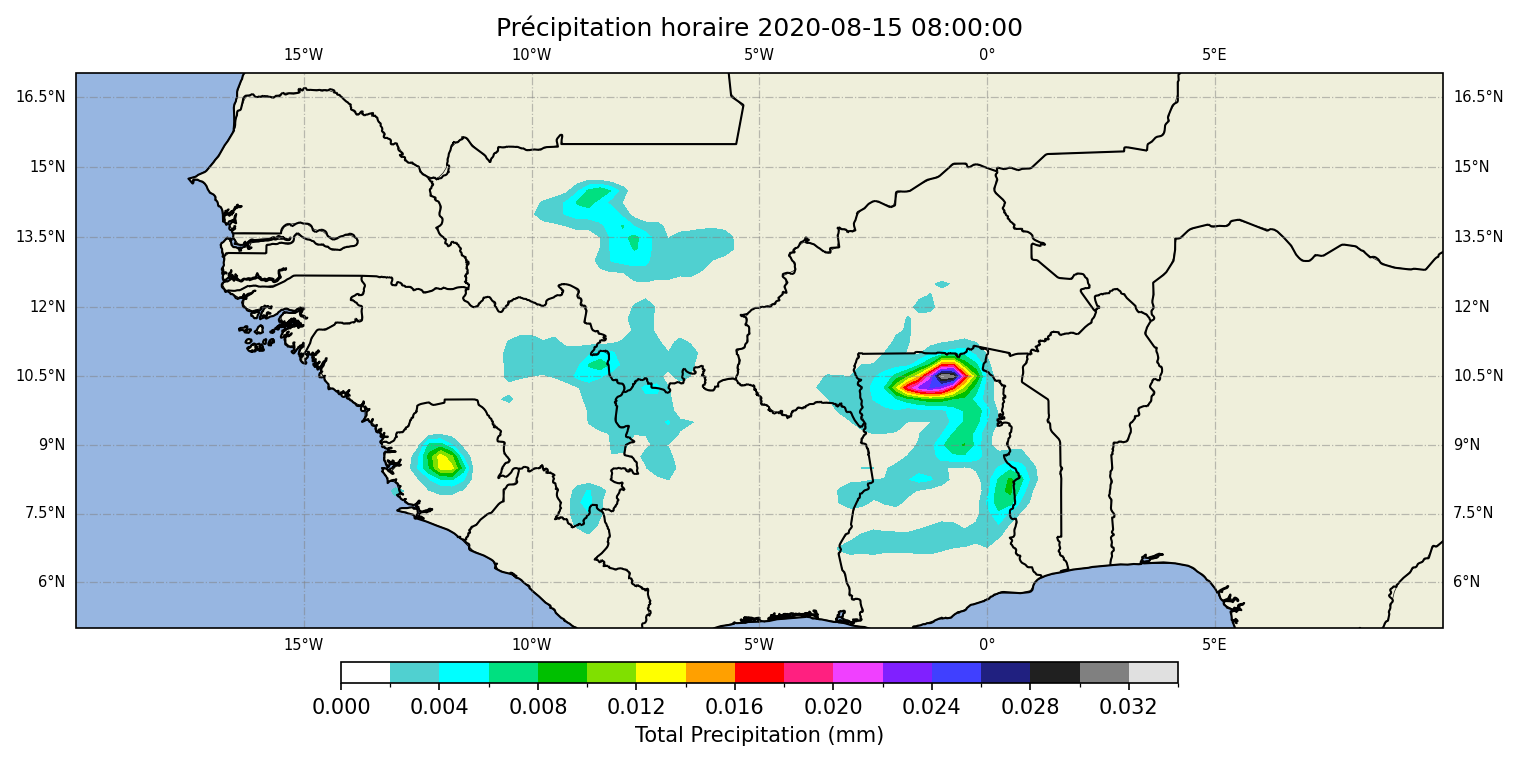

In [30]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
plt.rcParams['figure.facecolor'] = 'white'
#plt.style.use('seaborn')
import matplotlib.colors as mcolors
def plot_dataset(dataset : xr.Dataset):
    # First we specify Coordinate Refference System for Map Projection
    # We will use Mercator, which is a cylindrical, conformal projection. 
    # It has bery large distortion at high latitudes, cannot 
    # fully reach the polar regions.
    #projection = ccrs.Mercator()
    # Specify CRS, that will be used to tell the code, where should our data be plotted
    crs = ccrs.PlateCarree()
    # Now we will create axes object having specific projection 
    plt.figure(figsize=(12,6), dpi=150)
    ax = plt.axes(projection=projection, frameon=True)
    # Draw gridlines in degrees over Mercator map
    gl = ax.gridlines(crs=crs, draw_labels=True,
             linewidth=.6, color='gray', alpha=0.5, linestyle='-.')
    gl.xlabel_style = {"size" : 7}
    gl.ylabel_style = {"size" : 7}
    # To plot borders and coastlines, we can use cartopy feature
    import cartopy.feature as cf
    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
    ax.add_feature(cf.BORDERS.with_scale("50m"), lw=0.3)
##########################################################################
    #ax = fig.add_subplot(1, 1, 1, projection=projection)
    ax.add_feature(cfeature.BORDERS)
    #ax.add_feature(cfeature.LAKES)
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    #ax.add_feature(cfeature.RIVERS)
    ax.add_feature(cfeature.COASTLINE)
    ax.set_extent([-25, 15, 4, 20])
    #ax.stock_img()
    

    
    # Now, we will specify extent of our map in minimum/maximum longitude/latitude
    # Note that these values are specified in degrees of longitude and degrees of latitude
    # However, we can specify them in any crs that we want, but we need to provide appropriate
    # crs argument in ax.set_extent
    lon_min = -20
    lon_max = 10
    lat_min = 5
    lat_max = 17
    # crs is PlateCarree -> we are explicitly telling axes, that we are creating bounds that are in degrees
    ##### WE ADDED THESE LINES #####
     # draw filled contours.
    clevs = [0.000,0.002 , 0.004, 0.006, 0.008, 0.010, 0.012, 0.014, 0.016, 0.018,
          0.020, 0.022, 0.024, 0.026, 0.028, 0.030, 0.032, 0.035]
    # In future MetPy
    cmap_data = [(1, 0, 0, 0),
          (0.3137255012989044, 0.8156862854957581, 0.8156862854957581),
             (0.0, 1.0, 1.0),
             (0.0, 0.8784313797950745, 0.501960813999176),
             (0.0, 0.7529411911964417, 0.0),
             (0.501960813999176, 0.8784313797950745, 0.0),
             (1.0, 1.0, 0.0),
             (1.0, 0.6274510025978088, 0.0),
             (1.0, 0.0, 0.0),
             (1.0, 0.125490203499794, 0.501960813999176),
             (0.9411764740943909, 0.250980406999588, 1.0),
             (0.501960813999176, 0.125490203499794, 1.0),
             (0.250980406999588, 0.250980406999588, 1.0),
             (0.125490203499794, 0.125490203499794, 0.501960813999176),
             (0.125490203499794, 0.125490203499794, 0.125490203499794),
             (0.501960813999176, 0.501960813999176, 0.501960813999176),
             (0.8784313797950745, 0.8784313797950745, 0.8784313797950745),
                  ]
   

    cmap = mcolors.ListedColormap(cmap_data, "precipitation")
    norm = mcolors.BoundaryNorm(clevs, cmap.N)
    
    # Tri des coordonnées avant le tracé
    cbar_kwargs = {'orientation':'horizontal', 'shrink':0.6, "pad" : .05, 'aspect':40, 'label':'Total Precipitation (mm)'}
    dataset["Total_precip"].plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs=cbar_kwargs, levels=clevs,cmap=cmap, norm=norm)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)
    
    plt.title("Précipitation horaire 2020-08-15 08:00:00")
    plt.show()

plot_dataset(ds)

## ✅ Version adaptée pour DataFrame

In [11]:
df=df.reset_index()
df

,index,time,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction,Total_precip
0,0,2020-06-15 23:34:45.955674112,7.0,9.0,295.54570,0.000013,221.45150,32.052254,0.000146,-7.847553,-3.669004,0.114311,0.240737
1,1,2020-06-16 00:57:13.757999104,3.0,10.0,299.83463,0.000013,120.10258,73.223070,0.000021,-19.092920,7.343748,0.054014,0.106789
2,2,2020-06-16 01:38:27.659161600,-1.0,12.0,304.45767,0.000019,743.68940,90.161840,0.010897,-15.120418,3.149213,0.022672,0.046901
3,3,2020-06-16 03:23:49.851021312,8.0,11.0,301.77924,0.000015,532.67505,82.088690,0.004334,-18.381275,0.332186,0.026713,0.057856
4,4,2020-06-16 03:39:51.923695616,-20.0,17.0,303.67838,300.356800,191.85150,105.836754,0.000375,-2.009059,14.822785,0.036297,0.031632
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249684,1249684,2020-11-30 05:06:08.256278528,4.0,9.0,297.19934,0.000039,993.90894,91.489910,0.017674,-4.456836,-0.249225,0.144732,0.048088
1249685,1249685,2020-11-30 05:19:52.889999360,-20.0,16.0,299.76800,0.000006,970.94165,71.106390,0.011300,4.684550,-3.300973,0.179759,0.051704
1249686,1249686,2020-11-30 05:58:49.352208384,-20.0,14.0,297.44876,0.000008,337.09146,69.078830,0.001700,5.160214,4.269507,0.911677,0.223948
1249687,1249687,2020-11-30 06:26:18.619650048,-3.0,13.0,298.68912,0.000021,995.75390,47.217537,0.014540,3.847840,-4.751749,0.073988,0.022654


## ✅ Version adaptée pour DataFrame

In [1]:
## chargement de la data initiale
import pandas as pd
import numpy as np
#import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/validate_synthetic.csv")
print(df.shape)

(1249689, 12)


In [2]:
df

,time,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction,Total_precip
0,2020-06-15 23:34:45.955674112,7.326290,8.643314,295.54570,0.000013,221.45150,32.052254,0.000146,-7.847553,-3.669004,0.114311,0.240737
1,2020-06-16 00:57:13.757999104,2.919444,10.189704,299.83463,0.000013,120.10258,73.223070,0.000021,-19.092920,7.343748,0.054014,0.106789
2,2020-06-16 01:38:27.659161600,-1.232353,12.436743,304.45767,0.000019,743.68940,90.161840,0.010897,-15.120418,3.149213,0.022672,0.046901
3,2020-06-16 03:23:49.851021312,7.610665,11.168816,301.77924,0.000015,532.67505,82.088690,0.004334,-18.381275,0.332186,0.026713,0.057856
4,2020-06-16 03:39:51.923695616,-19.800112,16.910606,303.67838,300.356800,191.85150,105.836754,0.000375,-2.009059,14.822785,0.036297,0.031632
...,...,...,...,...,...,...,...,...,...,...,...,...
1249684,2020-11-30 05:06:08.256278528,4.228921,9.387922,297.19934,0.000039,993.90894,91.489910,0.017674,-4.456836,-0.249225,0.144732,0.048088
1249685,2020-11-30 05:19:52.889999360,-19.617558,16.425592,299.76800,0.000006,970.94165,71.106390,0.011300,4.684550,-3.300973,0.179759,0.051704
1249686,2020-11-30 05:58:49.352208384,-19.789116,14.353416,297.44876,0.000008,337.09146,69.078830,0.001700,5.160214,4.269507,0.911677,0.223948
1249687,2020-11-30 06:26:18.619650048,-3.319306,13.421268,298.68912,0.000021,995.75390,47.217537,0.014540,3.847840,-4.751749,0.073988,0.022654


In [3]:
# Permet de ramener time au format datetime apres le test
df['time'] = pd.to_datetime(df['time']).dt.round('H')
df

/tmp/ipykernel_6852/1354082687.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['time'] = pd.to_datetime(df['time']).dt.round('H')


,time,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction,Total_precip
0,2020-06-16 00:00:00,7.326290,8.643314,295.54570,0.000013,221.45150,32.052254,0.000146,-7.847553,-3.669004,0.114311,0.240737
1,2020-06-16 01:00:00,2.919444,10.189704,299.83463,0.000013,120.10258,73.223070,0.000021,-19.092920,7.343748,0.054014,0.106789
2,2020-06-16 02:00:00,-1.232353,12.436743,304.45767,0.000019,743.68940,90.161840,0.010897,-15.120418,3.149213,0.022672,0.046901
3,2020-06-16 03:00:00,7.610665,11.168816,301.77924,0.000015,532.67505,82.088690,0.004334,-18.381275,0.332186,0.026713,0.057856
4,2020-06-16 04:00:00,-19.800112,16.910606,303.67838,300.356800,191.85150,105.836754,0.000375,-2.009059,14.822785,0.036297,0.031632
...,...,...,...,...,...,...,...,...,...,...,...,...
1249684,2020-11-30 05:00:00,4.228921,9.387922,297.19934,0.000039,993.90894,91.489910,0.017674,-4.456836,-0.249225,0.144732,0.048088
1249685,2020-11-30 05:00:00,-19.617558,16.425592,299.76800,0.000006,970.94165,71.106390,0.011300,4.684550,-3.300973,0.179759,0.051704
1249686,2020-11-30 06:00:00,-19.789116,14.353416,297.44876,0.000008,337.09146,69.078830,0.001700,5.160214,4.269507,0.911677,0.223948
1249687,2020-11-30 06:00:00,-3.319306,13.421268,298.68912,0.000021,995.75390,47.217537,0.014540,3.847840,-4.751749,0.073988,0.022654


In [4]:
# Arrondir les coordonnées
df['latitude'] = df['latitude'].round(0)
df['longitude'] = df['longitude'].round(0)
df

,time,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction,Total_precip
0,2020-06-16 00:00:00,7.0,9.0,295.54570,0.000013,221.45150,32.052254,0.000146,-7.847553,-3.669004,0.114311,0.240737
1,2020-06-16 01:00:00,3.0,10.0,299.83463,0.000013,120.10258,73.223070,0.000021,-19.092920,7.343748,0.054014,0.106789
2,2020-06-16 02:00:00,-1.0,12.0,304.45767,0.000019,743.68940,90.161840,0.010897,-15.120418,3.149213,0.022672,0.046901
3,2020-06-16 03:00:00,8.0,11.0,301.77924,0.000015,532.67505,82.088690,0.004334,-18.381275,0.332186,0.026713,0.057856
4,2020-06-16 04:00:00,-20.0,17.0,303.67838,300.356800,191.85150,105.836754,0.000375,-2.009059,14.822785,0.036297,0.031632
...,...,...,...,...,...,...,...,...,...,...,...,...
1249684,2020-11-30 05:00:00,4.0,9.0,297.19934,0.000039,993.90894,91.489910,0.017674,-4.456836,-0.249225,0.144732,0.048088
1249685,2020-11-30 05:00:00,-20.0,16.0,299.76800,0.000006,970.94165,71.106390,0.011300,4.684550,-3.300973,0.179759,0.051704
1249686,2020-11-30 06:00:00,-20.0,14.0,297.44876,0.000008,337.09146,69.078830,0.001700,5.160214,4.269507,0.911677,0.223948
1249687,2020-11-30 06:00:00,-3.0,13.0,298.68912,0.000021,995.75390,47.217537,0.014540,3.847840,-4.751749,0.073988,0.022654


In [18]:
# Enregistrement en CSV
validate_data.to_csv("validate_synthetic.csv", index=True)

print("✅ Fichier sauvegardé : validate_synthetic.csv")


✅ Fichier sauvegardé : validate_synthetic.csv


In [18]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from cartopy.io.shapereader import natural_earth
import cartopy.io.shapereader as shpreader
import os

def plot_dataframe_precip(df, var="Total_precip", title="Carte des précipitations",save_path=None):
    projection = ccrs.PlateCarree()
    crs = ccrs.PlateCarree()
    
    plt.figure(figsize=(14,7), dpi=150)
    ax = plt.axes(projection=projection, frameon=True)

    # Grille
    gl = ax.gridlines(crs=crs, draw_labels=True, linewidth=.6, color='gray', alpha=0.5, linestyle='-.')
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    # Fond de carte
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.5)
    ##########################################################################
    #ax = fig.add_subplot(1, 1, 1, projection=projection)
    ax.add_feature(cfeature.BORDERS)
    #ax.add_feature(cfeature.LAKES)
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    #ax.add_feature(cfeature.RIVERS)
    ax.add_feature(cfeature.COASTLINE)
    ax.set_extent([-25, 15, 4, 20])
   
    # Étendue selon les données
    lon_min, lon_max = df["longitude"].min(), df["longitude"].max()
    lat_min, lat_max = df["latitude"].min(), df["latitude"].max()
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)

    # Palette et niveaux plus contrastés
    # draw filled contours.
    clevs = [0.000,0.002 , 0.004, 0.006, 0.008, 0.010, 0.012, 0.014, 0.016, 0.018,
          0.020, 0.022, 0.024, 0.026, 0.028, 0.030, 0.032, 0.035]
    # In future MetPy
    cmap_data = [(1, 0, 0, 0),
          (0.3137255012989044, 0.8156862854957581, 0.8156862854957581),
             (0.0, 1.0, 1.0),
             (0.0, 0.8784313797950745, 0.501960813999176),
             (0.0, 0.7529411911964417, 0.0),
             (0.501960813999176, 0.8784313797950745, 0.0),
             (1.0, 1.0, 0.0),
             (1.0, 0.6274510025978088, 0.0),
             (1.0, 0.0, 0.0),
             (1.0, 0.125490203499794, 0.501960813999176),
             (0.9411764740943909, 0.250980406999588, 1.0),
             (0.501960813999176, 0.125490203499794, 1.0),
             (0.250980406999588, 0.250980406999588, 1.0),
             (0.125490203499794, 0.125490203499794, 0.501960813999176),
             (0.125490203499794, 0.125490203499794, 0.125490203499794),
             (0.501960813999176, 0.501960813999176, 0.501960813999176),
             (0.8784313797950745, 0.8784313797950745, 0.8784313797950745),
                  ]
    cmap = mcolors.ListedColormap(cmap_data, "precipitation")
    norm = mcolors.BoundaryNorm(clevs, cmap.N)

    # Tracé des précipitations
    sc = ax.tricontourf(df["longitude"], df["latitude"], df[var],
                        levels=clevs, cmap=cmap, norm=norm, transform=crs)
    cbar = plt.colorbar(sc, orientation="horizontal", shrink=0.7, pad=0.05, aspect=40)
    cbar.set_label("Précipitations (m)", fontsize=10)

    # Villes principales
    cities = {
        "Dakar": (-17.45, 14.7), "Bamako": (-8.0, 12.65),
        "Abidjan": (-4.0, 5.3), "Ouagadougou": (-1.5, 12.35),
        "Niamey": (2.1, 13.5), "Lagos": (3.39, 6.45),
        "Accra": (-0.19, 5.56), "Lomé": (1.22, 6.13),
        "Cotonou": (2.43, 6.37), "Conakry": (-13.71, 9.64),
        "Freetown": (-13.23, 8.48), "Monrovia": (-10.8, 6.31),
        "Banjul": (-16.57, 13.45), "Praia": (-23.51, 14.93)
    }
    for city, (lon, lat) in cities.items():
        if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
            ax.plot(lon, lat, "ko", markersize=4, transform=crs)
            ax.text(lon+0.3, lat+0.3, city, fontsize=8, fontweight="bold", transform=crs)

    # Noms des pays
    shpfilename = natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
    for country in shpreader.Reader(shpfilename).records():
        geom = country.geometry
        if geom.centroid.x >= lon_min and geom.centroid.x <= lon_max and \
           geom.centroid.y >= lat_min and geom.centroid.y <= lat_max:
            ax.text(geom.centroid.x, geom.centroid.y, country.attributes['NAME'], 
                    fontsize=6, color='black', alpha=0.4, ha='center', transform=crs)

    plt.title(title, fontsize=14)
    # === Enregistrement si save_path fourni ===
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Figure enregistrée : {save_path}")
    plt.show()


## 🔎 Exemple d’utilisation

/home/oem/anaconda3/envs/climate-env/lib/python3.10/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


ValueError: Axis limits cannot be NaN or Inf

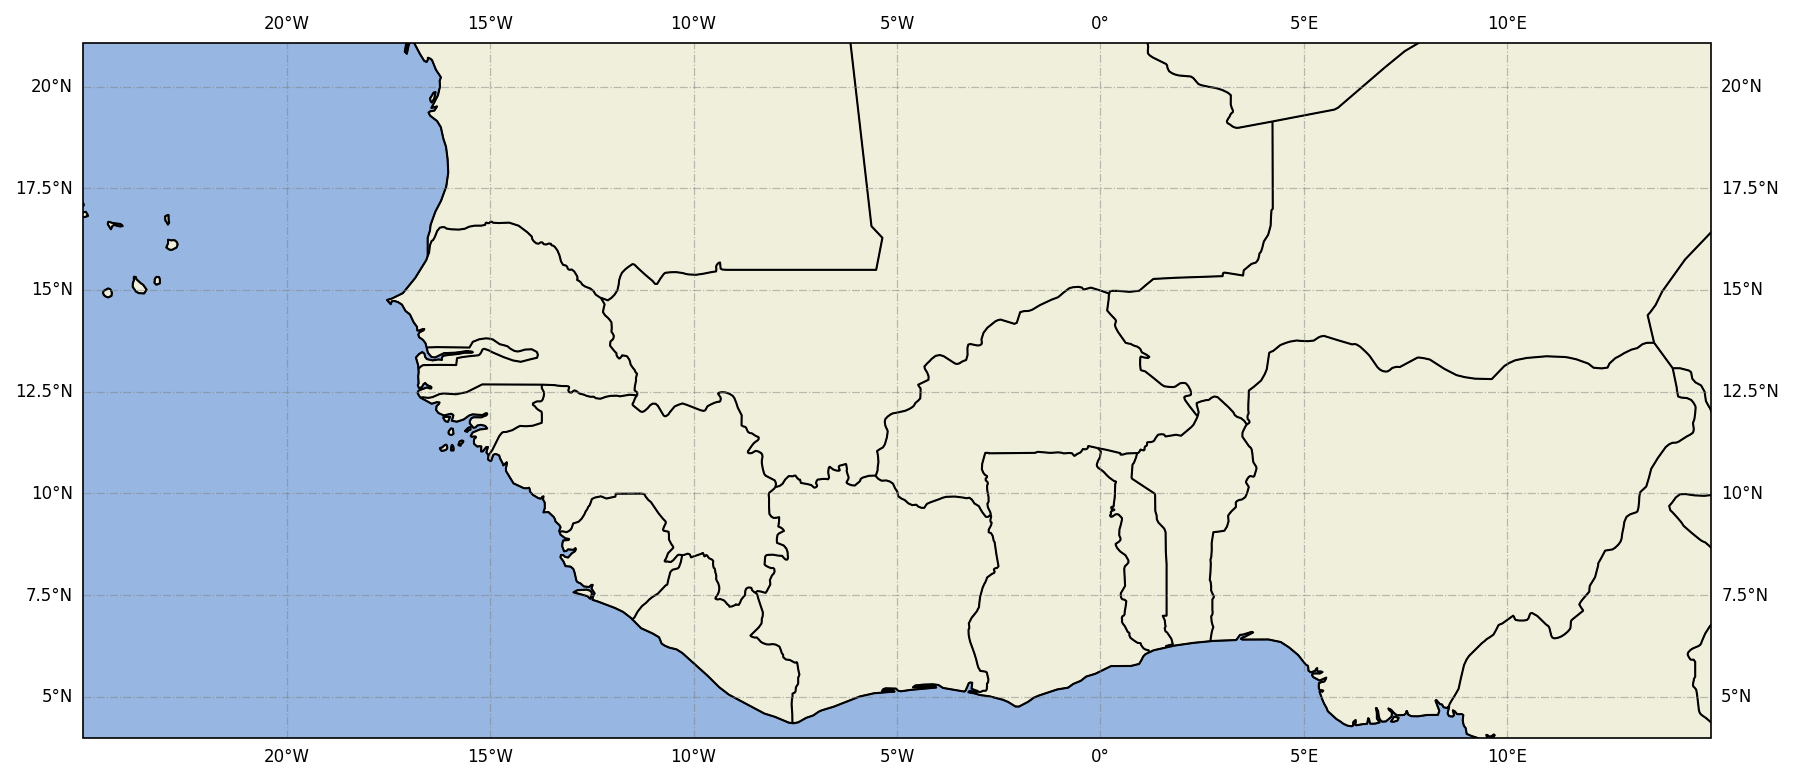

In [19]:
# Filtrer un pas de temps si besoin
df_time = validate_data[validate_data["time"] == "2020-06-15 12:00:00"]

plot_dataframe_precip(
    df_time,
    var="Total_precip",
    title="Précipitations du 15 juin 2023 à 12h",
   save_path= "/home/oem/Documents/these/code/visualise_climate_data/"
)


In [39]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from cartopy.io.shapereader import natural_earth
import cartopy.io.shapereader as shpreader
import os
import pandas as pd

def plot_compare_precip(df, var1="Total_precip", var2="Prediction",
                        title="Comparaison précipitations", save_path=None, date=None):
    """
    Compare deux variables (observée et prédite) sur deux cartes distinctes.
    Exemple : Total_precip vs Prediction
    """
    # === Filtrer par date si spécifié ===
    if date is not None:
        df = df[
            (df["time"] >= pd.to_datetime(date)) &
            (df["time"] < pd.to_datetime(date) + pd.Timedelta(days=1))
        ]
        if df.empty:
            print(f"⚠️ Aucun point trouvé pour la date {date}")
            return
    
    projection = ccrs.PlateCarree()
    crs = ccrs.PlateCarree()

    # Étendue selon les données
    lon_min, lon_max = df["longitude"].min(), df["longitude"].max()
    lat_min, lat_max = df["latitude"].min(), df["latitude"].max()

    # Palette et niveaux
    clevs = [0.000,0.002,0.004,0.006,0.008,0.010,0.012,0.014,0.016,0.018,
             0.020,0.022,0.024,0.026,0.028,0.030,0.032,0.035]
    cmap_data = [(1, 0, 0, 0),
          (0.3137, 0.8157, 0.8157),
          (0.0, 1.0, 1.0),
          (0.0, 0.878, 0.502),
          (0.0, 0.753, 0.0),
          (0.502, 0.878, 0.0),
          (1.0, 1.0, 0.0),
          (1.0, 0.627, 0.0),
          (1.0, 0.0, 0.0),
          (1.0, 0.125, 0.502),
          (0.941, 0.251, 1.0),
          (0.502, 0.125, 1.0),
          (0.251, 0.251, 1.0),
          (0.125, 0.125, 0.502),
          (0.125, 0.125, 0.125),
          (0.502, 0.502, 0.502),
          (0.878, 0.878, 0.878)]
    cmap = mcolors.ListedColormap(cmap_data, "precipitation")
    norm = mcolors.BoundaryNorm(clevs, cmap.N)

    # === Création figure à 2 cartes ===
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150,
                             subplot_kw={'projection': projection})

    for ax, var, subtitle in zip(axes, [var1, var2], ["Observé", "Prédit"]):
        # Fond de carte
        ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.7)
        ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.5)
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)

        # Tracé
        sc = ax.tricontourf(df["longitude"], df["latitude"], df[var],
                            levels=clevs, cmap=cmap, norm=norm, transform=crs)

        # Villes principales
        cities = {
            "Dakar": (-17.45, 14.7), "Bamako": (-8.0, 12.65),
            "Abidjan": (-4.0, 5.3), "Ouagadougou": (-1.5, 12.35),
            "Niamey": (2.1, 13.5), "Lagos": (3.39, 6.45),
            "Accra": (-0.19, 5.56), "Lomé": (1.22, 6.13),
            "Cotonou": (2.43, 6.37), "Conakry": (-13.71, 9.64),
            "Freetown": (-13.23, 8.48), "Monrovia": (-10.8, 6.31),
            "Banjul": (-16.57, 13.45), "Praia": (-23.51, 14.93)
        }
        for city, (lon, lat) in cities.items():
            if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
                ax.plot(lon, lat, "ko", markersize=4, transform=crs)
                ax.text(lon+0.3, lat+0.3, city, fontsize=7, fontweight="bold", transform=crs)

        # Noms des pays
        shpfilename = natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
        for country in shpreader.Reader(shpfilename).records():
            geom = country.geometry
            if lon_min <= geom.centroid.x <= lon_max and lat_min <= geom.centroid.y <= lat_max:
                ax.text(geom.centroid.x, geom.centroid.y, country.attributes['NAME'],
                        fontsize=6, color='black', alpha=0.4, ha='center', transform=crs)

        ax.set_title(f"{subtitle} ({var})")

    # Colorbar commune
    cbar = fig.colorbar(sc, ax=axes, orientation="horizontal", shrink=0.7, pad=0.05, aspect=40)
    cbar.set_label("Précipitations (m)", fontsize=10)

    # Titre global
    fig.suptitle(title if date is None else f"{title} ({date})", fontsize=15)

    # Sauvegarde
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✅ Figure enregistrée : {save_path}")

    plt.show()


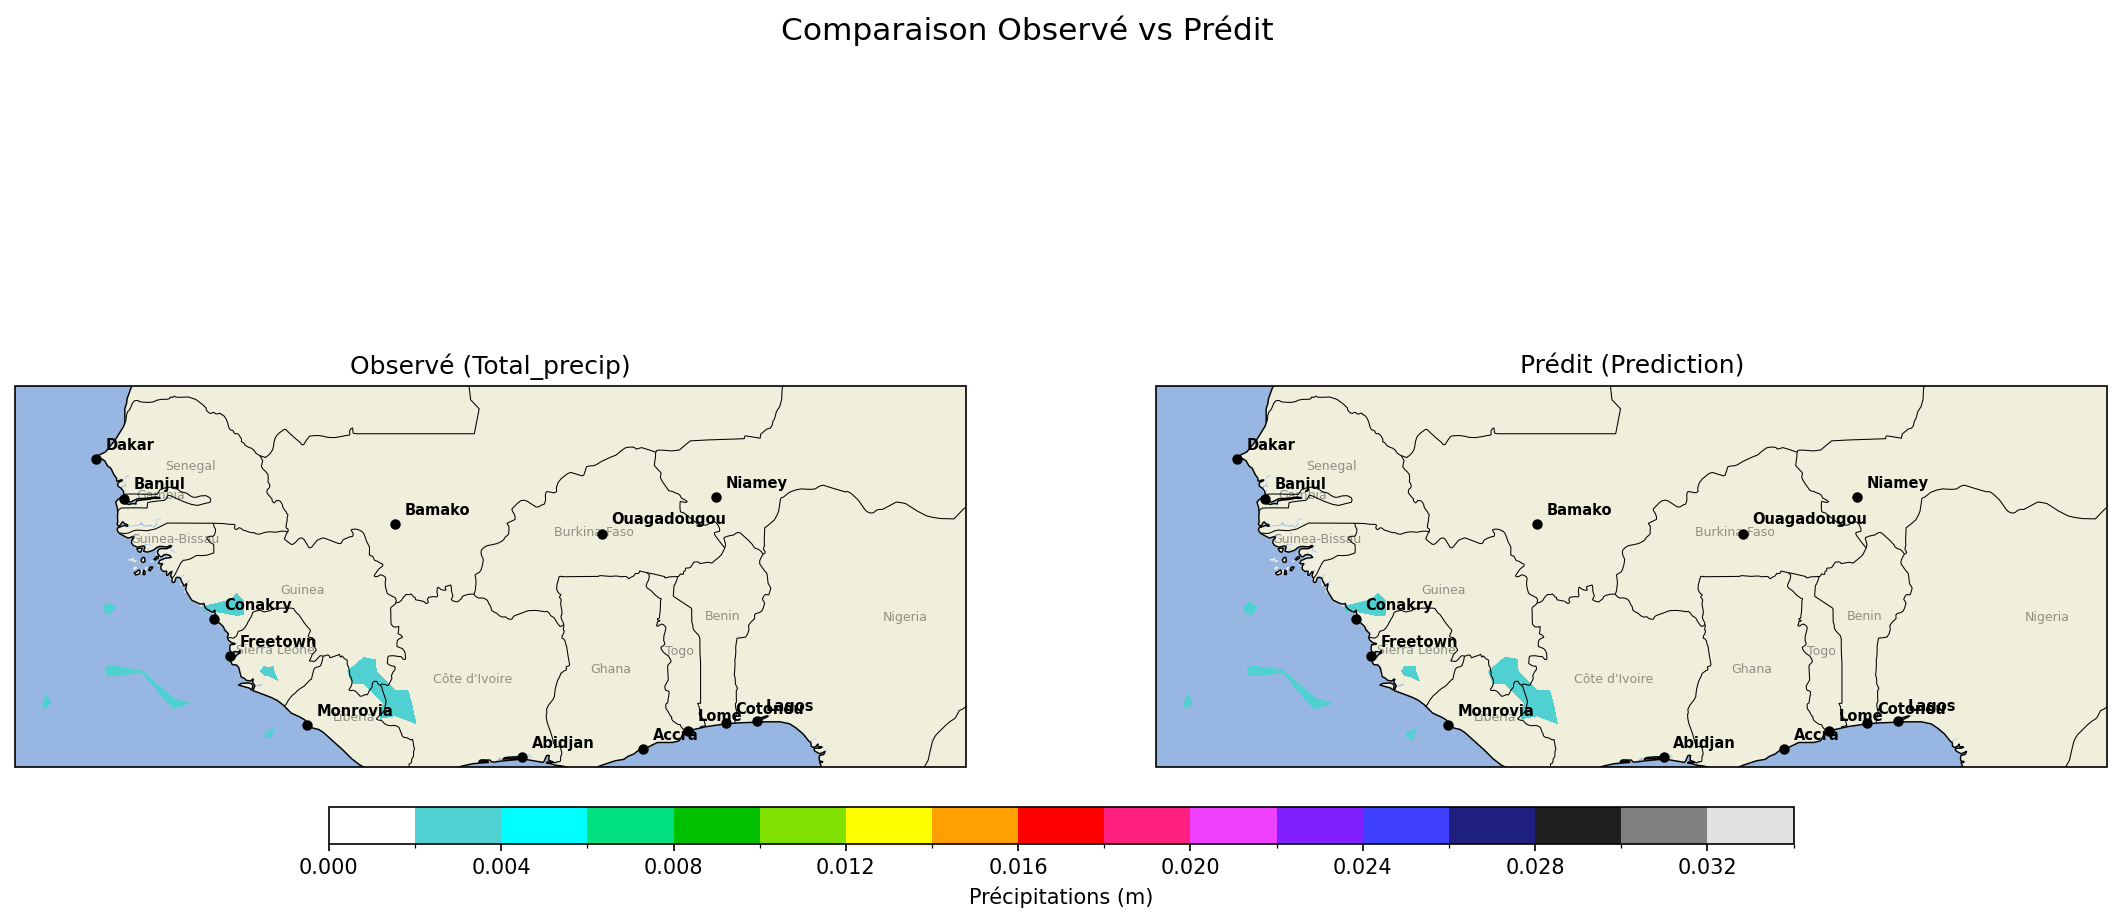

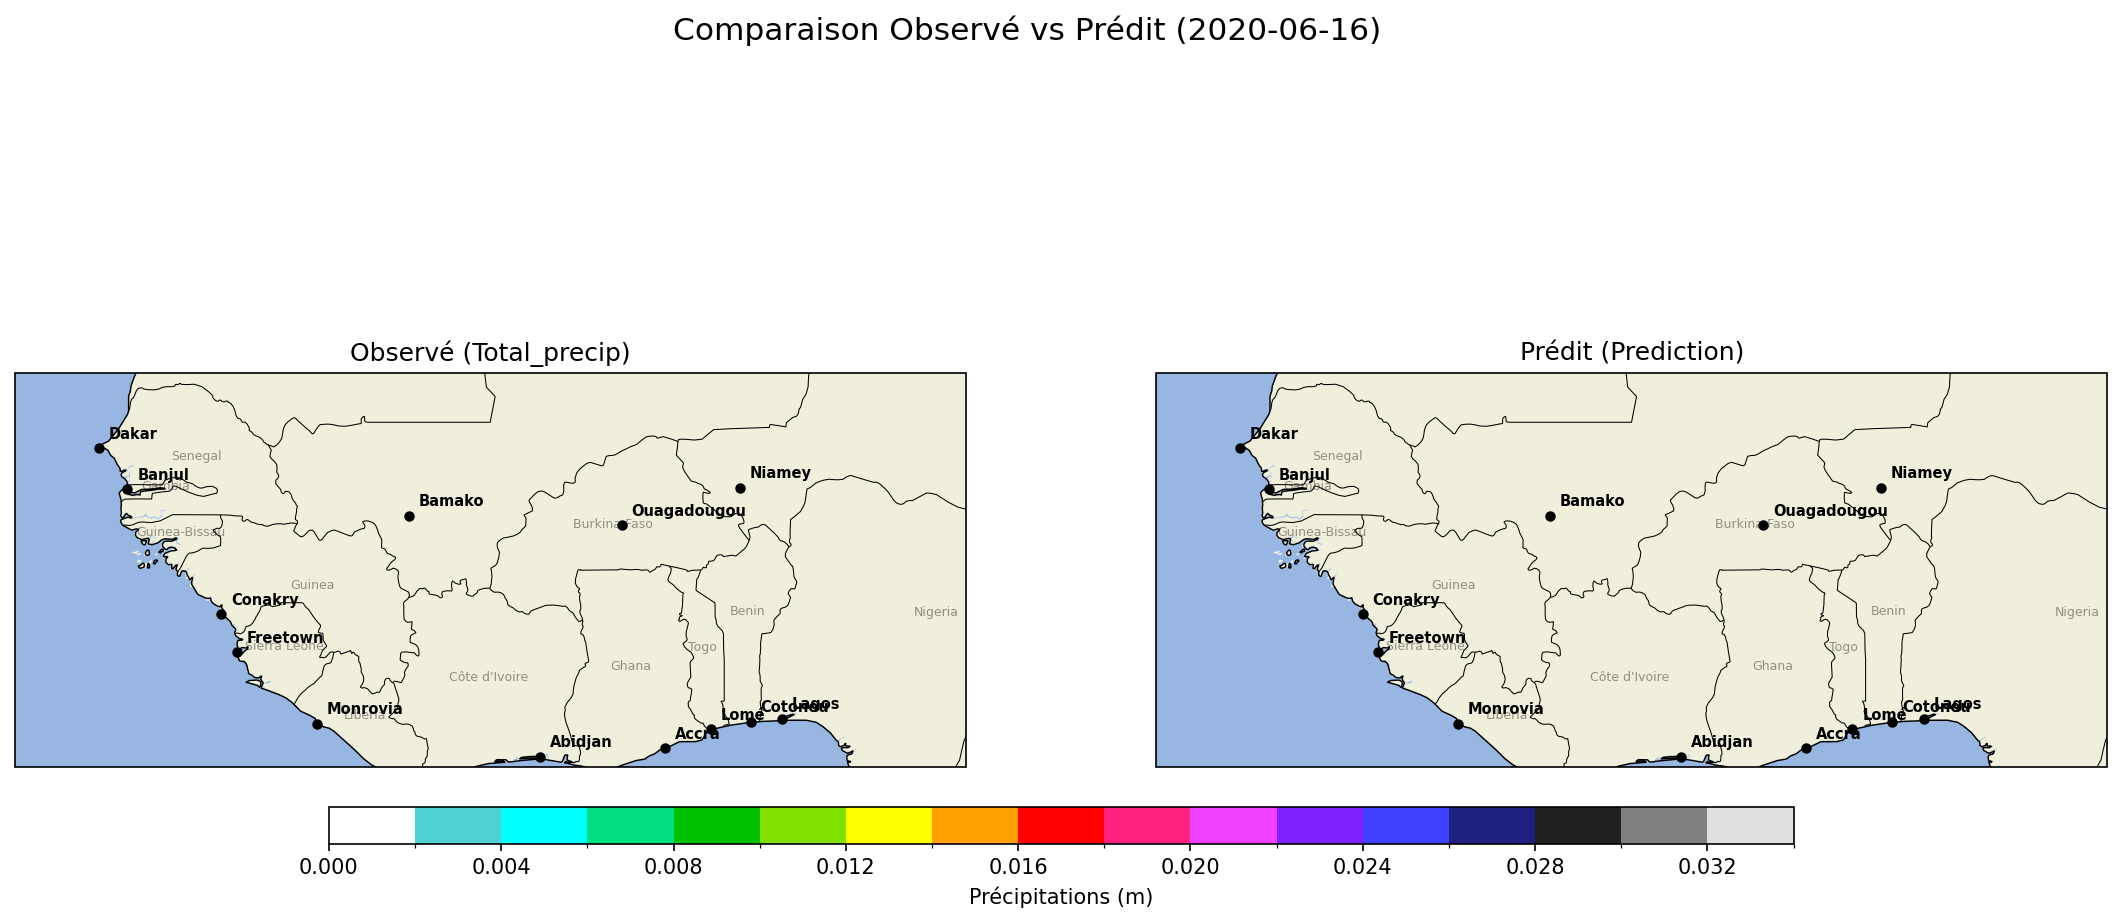

In [40]:
# Comparer sur toutes les données
plot_compare_precip(validate_data, var1="Total_precip", var2="Prediction", title="Comparaison Observé vs Prédit")

# Comparer sur une date spécifique
plot_compare_precip(validate_data, var1="Total_precip", var2="Prediction", title="Comparaison Observé vs Prédit", date="2020-06-16")


In [20]:
df_time

,time,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction,Total_precip


In [41]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from cartopy.io.shapereader import natural_earth
import cartopy.io.shapereader as shpreader
import os
import pandas as pd

def plot_compare_precip(df, var1="Total_precip", var2="Prediction",
                        title="Comparaison précipitations", save_path=None, date=None):
    """
    Compare deux variables (observée et prédite) et affiche aussi l'erreur (var2 - var1).
    Exemple : Total_precip vs Prediction + Différence
    """
    # === Filtrer par date si spécifié ===
    if date is not None:
        df = df[
            (df["time"] >= pd.to_datetime(date)) &
            (df["time"] < pd.to_datetime(date) + pd.Timedelta(days=1))
        ]
        if df.empty:
            print(f"⚠️ Aucun point trouvé pour la date {date}")
            return
    
    projection = ccrs.PlateCarree()
    crs = ccrs.PlateCarree()

    # Étendue selon les données
    lon_min, lon_max = df["longitude"].min(), df["longitude"].max()
    lat_min, lat_max = df["latitude"].min(), df["latitude"].max()

    # === Palette précipitations ===
    clevs = [0.000,0.002,0.004,0.006,0.008,0.010,0.012,0.014,0.016,0.018,
             0.020,0.022,0.024,0.026,0.028,0.030,0.032,0.035]
    cmap_data = [(1, 0, 0, 0),
          (0.3137, 0.8157, 0.8157),
          (0.0, 1.0, 1.0),
          (0.0, 0.878, 0.502),
          (0.0, 0.753, 0.0),
          (0.502, 0.878, 0.0),
          (1.0, 1.0, 0.0),
          (1.0, 0.627, 0.0),
          (1.0, 0.0, 0.0),
          (1.0, 0.125, 0.502),
          (0.941, 0.251, 1.0),
          (0.502, 0.125, 1.0),
          (0.251, 0.251, 1.0),
          (0.125, 0.125, 0.502),
          (0.125, 0.125, 0.125),
          (0.502, 0.502, 0.502),
          (0.878, 0.878, 0.878)]
    cmap = mcolors.ListedColormap(cmap_data, "precipitation")
    norm = mcolors.BoundaryNorm(clevs, cmap.N)

    # === Palette erreurs (différence) ===
    error_cmap = plt.cm.RdBu_r  # Rouge = surestimation, Bleu = sous-estimation
    error_norm = mcolors.TwoSlopeNorm(vcenter=0)  # centré sur 0

    # === Ajout de la colonne "erreur" ===
    df["Erreur"] = df[var2] - df[var1]

    # === Création figure à 3 cartes ===
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), dpi=150,
                             subplot_kw={'projection': projection})

    # Boucle sur les 3 cartes : Observé, Prédit, Erreur
    for ax, var, subtitle, cmap_used, norm_used in zip(
        axes,
        [var1, var2, "Erreur"],
        ["Observé", "Prédit", "Erreur (Prédit - Observé)"],
        [cmap, cmap, error_cmap],
        [norm, norm, error_norm]
    ):
        # Fond de carte
        ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.7)
        ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.5)
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)

        # Tracé
        sc = ax.tricontourf(df["longitude"], df["latitude"], df[var],
                            levels=20 if var == "Erreur" else clevs,
                            cmap=cmap_used, norm=norm_used, transform=crs)

        # Villes principales
        cities = {
            "Dakar": (-17.45, 14.7), "Bamako": (-8.0, 12.65),
            "Abidjan": (-4.0, 5.3), "Ouagadougou": (-1.5, 12.35),
            "Niamey": (2.1, 13.5), "Lagos": (3.39, 6.45),
            "Accra": (-0.19, 5.56), "Lomé": (1.22, 6.13),
            "Cotonou": (2.43, 6.37), "Conakry": (-13.71, 9.64),
            "Freetown": (-13.23, 8.48), "Monrovia": (-10.8, 6.31),
            "Banjul": (-16.57, 13.45), "Praia": (-23.51, 14.93)
        }
        for city, (lon, lat) in cities.items():
            if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
                ax.plot(lon, lat, "ko", markersize=4, transform=crs)
                ax.text(lon+0.3, lat+0.3, city, fontsize=7, fontweight="bold", transform=crs)

        # Noms des pays
        shpfilename = natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
        for country in shpreader.Reader(shpfilename).records():
            geom = country.geometry
            if lon_min <= geom.centroid.x <= lon_max and lat_min <= geom.centroid.y <= lat_max:
                ax.text(geom.centroid.x, geom.centroid.y, country.attributes['NAME'],
                        fontsize=6, color='black', alpha=0.4, ha='center', transform=crs)

        ax.set_title(f"{subtitle} ({var})")

    # Colorbars
    fig.colorbar(sc, ax=axes[:2], orientation="horizontal", shrink=0.6, pad=0.05, aspect=40).set_label("Précipitations (m)", fontsize=10)
    fig.colorbar(sc, ax=axes[2], orientation="horizontal", shrink=0.6, pad=0.1, aspect=40).set_label("Erreur (m)", fontsize=10)

    # Titre global
    fig.suptitle(title if date is None else f"{title} ({date})", fontsize=15)

    # Sauvegarde
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✅ Figure enregistrée : {save_path}")

    plt.show()


/tmp/ipykernel_6443/2630871713.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Erreur"] = df[var2] - df[var1]


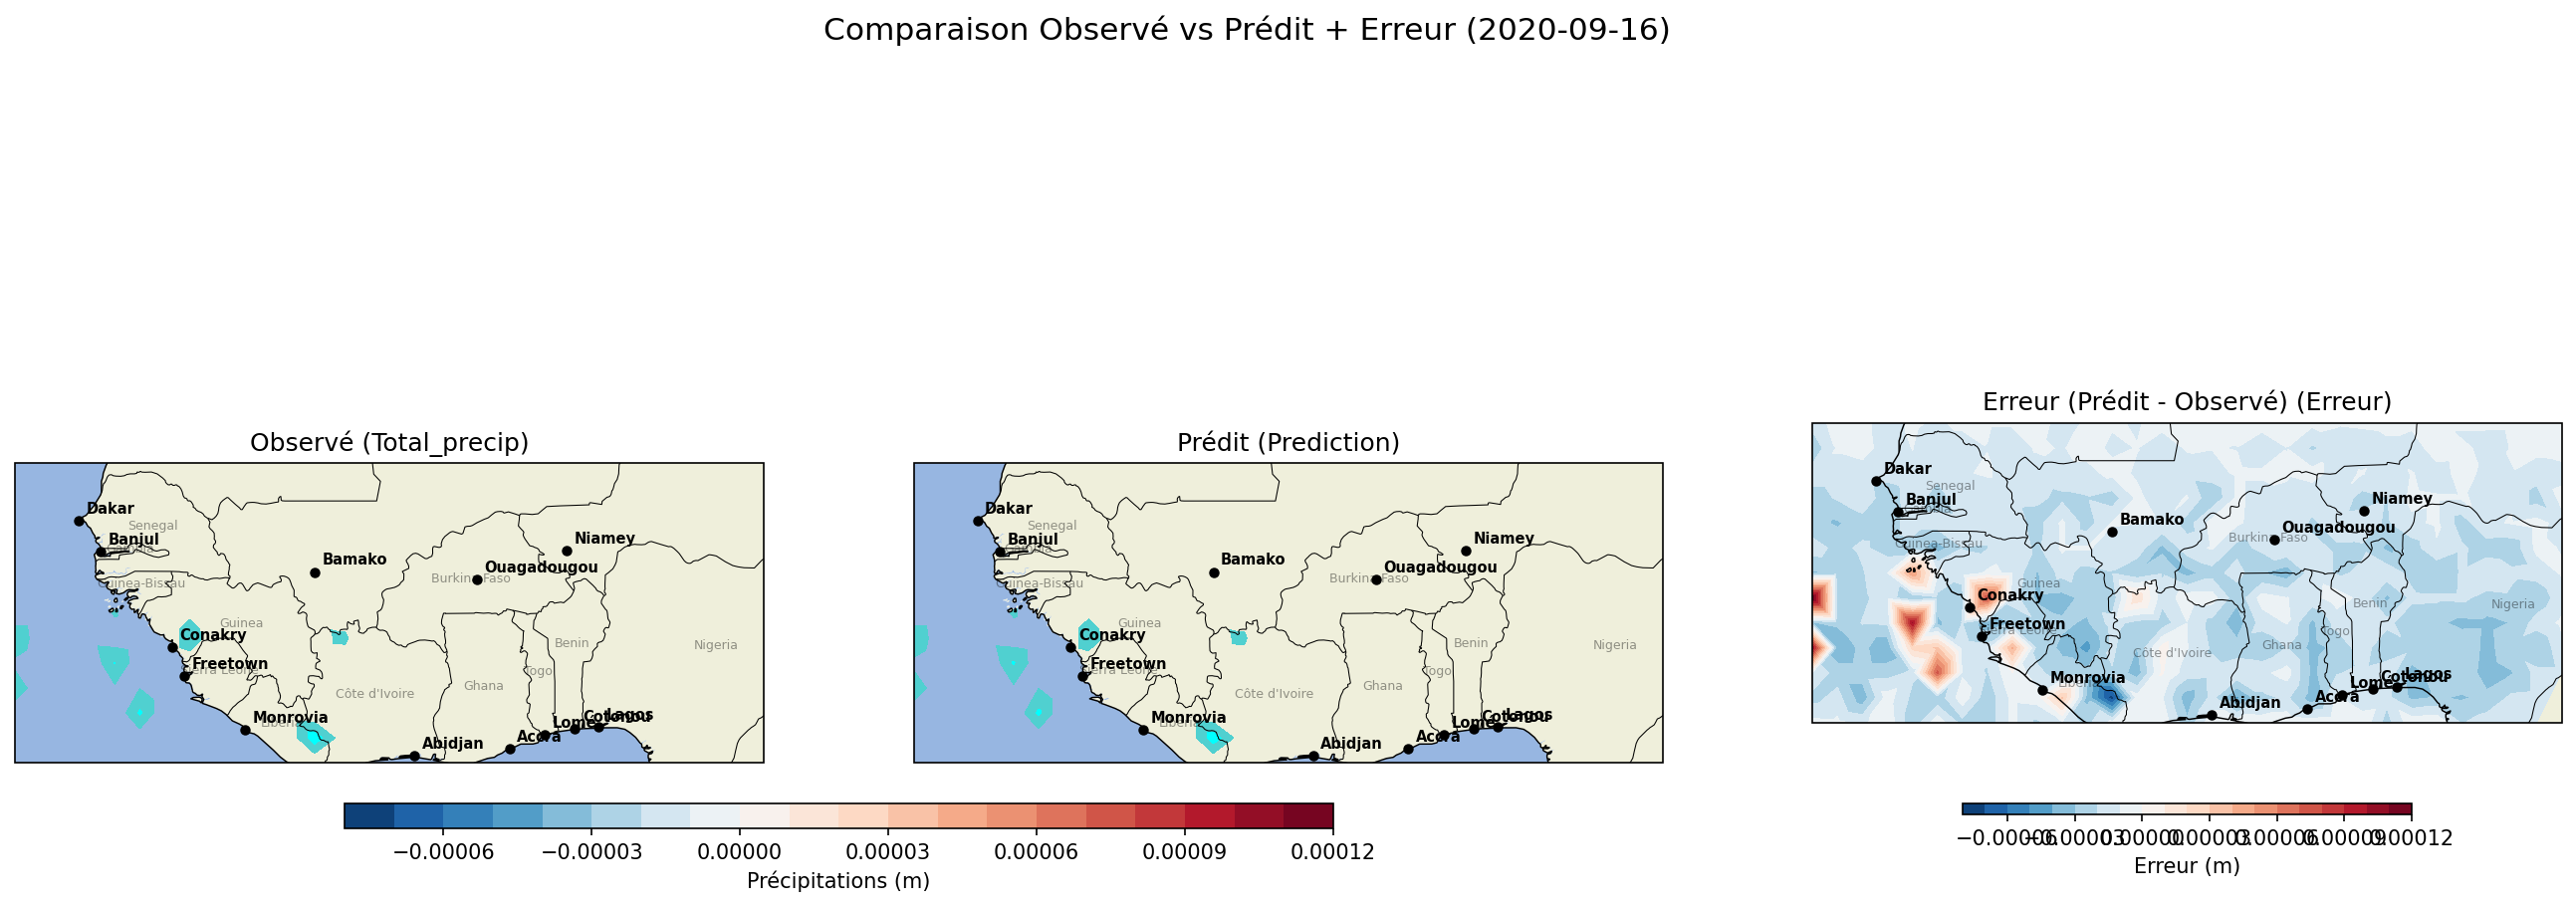

In [44]:
# Comparer avec la carte d’erreur incluse
plot_compare_precip(validate_data, var1="Total_precip", var2="Prediction",
                    title="Comparaison Observé vs Prédit + Erreur", date="2020-09-16")


In [48]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from cartopy.io.shapereader import natural_earth
import cartopy.io.shapereader as shpreader
import os
import pandas as pd
import numpy as np

def plot_compare_precip(df, var1="Total_precip", var2="Prediction",
                        title="Comparaison précipitations", save_path=None, date=None):
    """
    Compare deux variables (observée et prédite), affiche aussi l'erreur (var2 - var1)
    et calcule MAE, RMSE, Corrélation.
    """

    # === Filtrer par date si spécifié ===
    if date is not None:
        df = df[
            (df["time"] >= pd.to_datetime(date)) &
            (df["time"] < pd.to_datetime(date) + pd.Timedelta(days=1))
        ]
        if df.empty:
            print(f"⚠️ Aucun point trouvé pour la date {date}")
            return
    
    # === Calcul des métriques globales ===
    mae = np.mean(np.abs(df[var2] - df[var1]))
    rmse = np.sqrt(np.mean((df[var2] - df[var1])**2))
    corr = df[[var1, var2]].corr().iloc[0, 1]

    print(f"📊 MAE = {mae:.4f}, RMSE = {rmse:.4f}, Corrélation = {corr:.4f}")

    projection = ccrs.PlateCarree()
    crs = ccrs.PlateCarree()

    # Étendue selon les données
    lon_min, lon_max = df["longitude"].min(), df["longitude"].max()
    lat_min, lat_max = df["latitude"].min(), df["latitude"].max()

    # === Palette précipitations ===
    clevs = [0.000,0.002,0.004,0.006,0.008,0.010,0.012,0.014,0.016,0.018,
             0.020,0.022,0.024,0.026,0.028,0.030,0.032,0.035]
    cmap_data = [(1, 0, 0, 0),
          (0.3137, 0.8157, 0.8157),
          (0.0, 1.0, 1.0),
          (0.0, 0.878, 0.502),
          (0.0, 0.753, 0.0),
          (0.502, 0.878, 0.0),
          (1.0, 1.0, 0.0),
          (1.0, 0.627, 0.0),
          (1.0, 0.0, 0.0),
          (1.0, 0.125, 0.502),
          (0.941, 0.251, 1.0),
          (0.502, 0.125, 1.0),
          (0.251, 0.251, 1.0),
          (0.125, 0.125, 0.502),
          (0.125, 0.125, 0.125),
          (0.502, 0.502, 0.502),
          (0.878, 0.878, 0.878)]
    cmap = mcolors.ListedColormap(cmap_data, "precipitation")
    norm = mcolors.BoundaryNorm(clevs, cmap.N)

    # === Palette erreurs (différence) ===
    error_cmap = plt.cm.RdBu_r
    error_norm = mcolors.TwoSlopeNorm(vcenter=0)

    # === Ajout de la colonne "erreur" ===
    df["Erreur"] = df[var2] - df[var1]

    # === Création figure à 3 cartes ===
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), dpi=150,
                             subplot_kw={'projection': projection})

    for ax, var, subtitle, cmap_used, norm_used in zip(
        axes,
        [var1, var2, "Erreur"],
        ["Observé", "Prédit", "Erreur (Prédit - Observé)"],
        [cmap, cmap, error_cmap],
        [norm, norm, error_norm]
    ):
        ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.7)
        ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.5)
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)

        sc = ax.tricontourf(df["longitude"], df["latitude"], df[var],
                            levels=20 if var == "Erreur" else clevs,
                            cmap=cmap_used, norm=norm_used, transform=crs)

        # Villes
        cities = {
            "Dakar": (-17.45, 14.7), "Bamako": (-8.0, 12.65),
            "Abidjan": (-4.0, 5.3), "Ouagadougou": (-1.5, 12.35),
            "Niamey": (2.1, 13.5), "Lagos": (3.39, 6.45),
            "Accra": (-0.19, 5.56), "Lomé": (1.22, 6.13),
            "Cotonou": (2.43, 6.37), "Conakry": (-13.71, 9.64),
            "Freetown": (-13.23, 8.48), "Monrovia": (-10.8, 6.31),
            "Banjul": (-16.57, 13.45), "Praia": (-23.51, 14.93)
        }
        for city, (lon, lat) in cities.items():
            if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
                ax.plot(lon, lat, "ko", markersize=4, transform=crs)
                ax.text(lon+0.3, lat+0.3, city, fontsize=7, fontweight="bold", transform=crs)

        # Pays
        shpfilename = natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
        for country in shpreader.Reader(shpfilename).records():
            geom = country.geometry
            if lon_min <= geom.centroid.x <= lon_max and lat_min <= geom.centroid.y <= lat_max:
                ax.text(geom.centroid.x, geom.centroid.y, country.attributes['NAME'],
                        fontsize=6, color='black', alpha=0.4, ha='center', transform=crs)

        ax.set_title(f"{subtitle} ({var})")

    # Colorbars
    fig.colorbar(sc, ax=axes[:2], orientation="horizontal", shrink=0.6, pad=0.05, aspect=40).set_label("Précipitations (m)", fontsize=10)
    fig.colorbar(sc, ax=axes[2], orientation="horizontal", shrink=0.6, pad=0.1, aspect=40).set_label("Erreur (m)", fontsize=10)

    # Titre global avec métriques
    metrics_txt = f"MAE={mae:.10f} | RMSE={rmse:.10f} | Corr={corr:.3f}"
    fig.suptitle(f"{title} - {metrics_txt}" + (f" ({date})" if date else ""), fontsize=15)

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✅ Figure enregistrée : {save_path}")

    plt.show()


📊 MAE = 0.0000, RMSE = 0.0000, Corrélation = 0.9993


/tmp/ipykernel_6443/3827744924.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Erreur"] = df[var2] - df[var1]


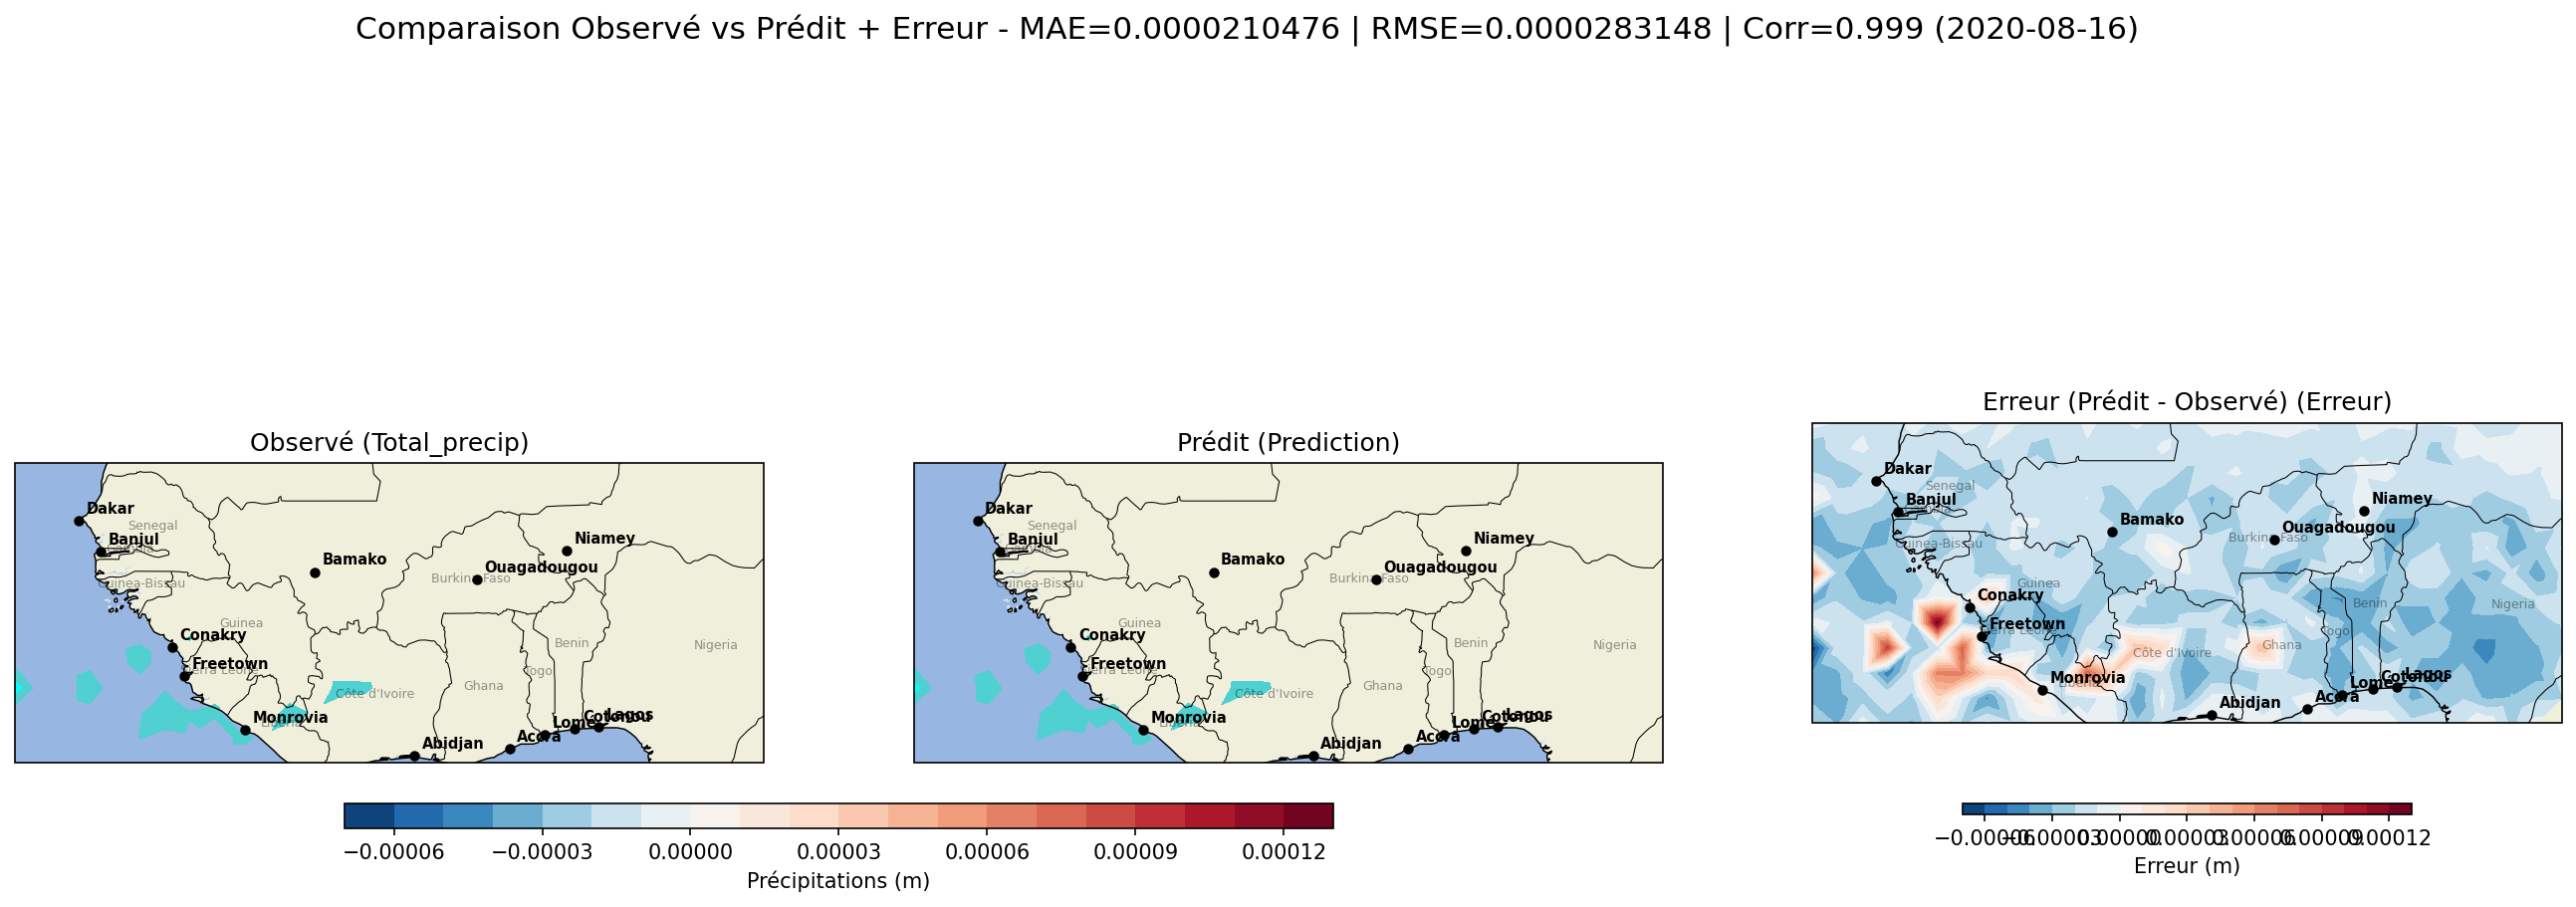

In [49]:
plot_compare_precip(validate_data, var1="Total_precip", var2="Prediction",
                    title="Comparaison Observé vs Prédit + Erreur",
                    date="2020-08-16")


In [5]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from cartopy.io.shapereader import natural_earth
import cartopy.io.shapereader as shpreader
import os
import pandas as pd
import numpy as np

def plot_error_precip(df, var1="Total_precip", var2="Prediction",
                      title="Erreur Précipitations", save_path=None, date=None):
    """
    Trace uniquement la carte de l'erreur (var2 - var1)
    et enregistre l'image directement.
    """

    # === Filtrer par date si spécifié ===
    if date is not None:
        df = df[
            (df["time"] >= pd.to_datetime(date)) &
            (df["time"] < pd.to_datetime(date) + pd.Timedelta(days=1))
        ]
        if df.empty:
            print(f"⚠️ Aucun point trouvé pour la date {date}")
            return
    
    # === Calcul métriques ===
    mae = np.mean(np.abs(df[var2] - df[var1]))
    rmse = np.sqrt(np.mean((df[var2] - df[var1])**2))
    corr = df[[var1, var2]].corr().iloc[0, 1]

    print(f"📊 MAE = {mae:.4f}, RMSE = {rmse:.4f}, Corrélation = {corr:.4f}")

    # Ajout colonne erreur
    df["Erreur"] = df[var2] - df[var1]

    projection = ccrs.PlateCarree()
    crs = ccrs.PlateCarree()

    # Étendue
    lon_min, lon_max = df["longitude"].min(), df["longitude"].max()
    lat_min, lat_max = df["latitude"].min(), df["latitude"].max()

    # Palette erreurs
    error_cmap = plt.cm.RdBu_r
    error_norm = mcolors.TwoSlopeNorm(vcenter=0)

    # === Création figure ===
    fig = plt.figure(figsize=(10, 7), dpi=150)
    ax = plt.axes(projection=projection)

    # Fond de carte
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.5)
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=crs)

    # Tracé erreur
    sc = ax.tricontourf(df["longitude"], df["latitude"], df["Erreur"],
                        levels=20, cmap=error_cmap, norm=error_norm, transform=crs)

    # Villes
    cities = {
        "Dakar": (-17.45, 14.7), "Bamako": (-8.0, 12.65),
        "Abidjan": (-4.0, 5.3), "Ouagadougou": (-1.5, 12.35),
        "Niamey": (2.1, 13.5), "Lagos": (3.39, 6.45),
        "Accra": (-0.19, 5.56), "Lomé": (1.22, 6.13),
        "Cotonou": (2.43, 6.37), "Conakry": (-13.71, 9.64),
        "Freetown": (-13.23, 8.48), "Monrovia": (-10.8, 6.31),
        "Banjul": (-16.57, 13.45), "Praia": (-23.51, 14.93)
    }
    for city, (lon, lat) in cities.items():
        if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
            ax.plot(lon, lat, "ko", markersize=4, transform=crs)
            ax.text(lon+0.3, lat+0.3, city, fontsize=7, fontweight="bold", transform=crs)

    # Pays
    shpfilename = natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
    for country in shpreader.Reader(shpfilename).records():
        geom = country.geometry
        if lon_min <= geom.centroid.x <= lon_max and lat_min <= geom.centroid.y <= lat_max:
            ax.text(geom.centroid.x, geom.centroid.y, country.attributes['NAME'],
                    fontsize=6, color='black', alpha=0.4, ha='center', transform=crs)

    # Colorbar
    cbar = plt.colorbar(sc, orientation="horizontal", shrink=0.7, pad=0.05, aspect=40)
    cbar.set_label("Erreur (mm)", fontsize=10)

    # Titre
    metrics_txt = f"MAE={mae:.10f} | RMSE={rmse:.10f} | Corr={corr:.3f}"
    plt.title(f"{title} - {metrics_txt}" + (f" ({date})" if date else ""), fontsize=13)

    # Enregistrement direct
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)  # fermeture après enregistrement
        print(f"✅ Figure enregistrée : {save_path}")
    else:
        plt.show()


In [7]:
def plot_error_precip_all_dates(df, var1="Total_precip", var2="Prediction",
                                title="Erreur Précipitations", save_dir="erreurs_cartes"):
    """
    Trace et enregistre la carte de l'erreur (var2 - var1) pour chaque date unique.
    Chaque figure est sauvegardée dans save_dir sans affichage à l'écran.
    """

    # Conversion du temps en datetime arrondi à l'heure
    df["time"] = pd.to_datetime(df["time"]).dt.round("h")

    # Liste des dates uniques (au format jour par jour)
    all_dates = df["time"].dt.floor("D").unique()
    print(f"📅 Nombre de dates trouvées : {len(all_dates)}")

    # Créer le dossier si nécessaire
    os.makedirs(save_dir, exist_ok=True)

    for date in all_dates:
        # Sous-échantillonner la date en cours
        df_date = df[(df["time"] >= date) & (df["time"] < date + pd.Timedelta(days=1))]

        if df_date.empty:
            continue

        # Nom du fichier de sortie
        filename = f"{title.replace(' ', '_')}_{pd.to_datetime(date).strftime('%Y%m%d')}.png"
        save_path = os.path.join(save_dir, filename)

        # Appeler la fonction précédente
        plot_error_precip(df_date, var1=var1, var2=var2,
                          title=title, save_path=save_path, date=date)

    print(f"✅ Toutes les cartes sauvegardées dans : {save_dir}")


In [8]:
plot_error_precip_all_dates(df,
                            var1="Total_precip",
                            var2="Prediction",
                            title="Precipitation Error",
                            save_dir="cartes_erreurs")


📅 Nombre de dates trouvées : 168
📊 MAE = 0.0863, RMSE = 0.1340, Corrélation = 0.9907
✅ Figure enregistrée : cartes_erreurs/Precipitation_Error_20200616.png
📊 MAE = 0.1119, RMSE = 0.2095, Corrélation = 0.9910
✅ Figure enregistrée : cartes_erreurs/Precipitation_Error_20200617.png
📊 MAE = 0.1102, RMSE = 0.1964, Corrélation = 0.9914
✅ Figure enregistrée : cartes_erreurs/Precipitation_Error_20200618.png
📊 MAE = 0.1306, RMSE = 0.2464, Corrélation = 0.9920
✅ Figure enregistrée : cartes_erreurs/Precipitation_Error_20200619.png
📊 MAE = 0.1306, RMSE = 0.2385, Corrélation = 0.9895
✅ Figure enregistrée : cartes_erreurs/Precipitation_Error_20200620.png
📊 MAE = 0.1162, RMSE = 0.2151, Corrélation = 0.9895
✅ Figure enregistrée : cartes_erreurs/Precipitation_Error_20200621.png
📊 MAE = 0.1331, RMSE = 0.2675, Corrélation = 0.9894
✅ Figure enregistrée : cartes_erreurs/Precipitation_Error_20200622.png
📊 MAE = 0.1308, RMSE = 0.2529, Corrélation = 0.9899
✅ Figure enregistrée : cartes_erreurs/Precipitation_Er

In [50]:
import os
import imageio
import pandas as pd

def plot_error_precip_all_dates(df, var1="Total_precip", var2="Prediction",
                                title="Precipitation Error", save_dir="cartes_erreurs"):
    """
    Génère une carte d'erreur absolue pour chaque date unique du DataFrame
    et les enregistre dans un dossier.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Extraire toutes les dates uniques
    dates = pd.to_datetime(df["time"]).dt.date.unique()
    dates = sorted(dates)

    print(f"📅 {len(dates)} dates trouvées")

    # Générer une figure par date
    for date in dates:
        save_path = os.path.join(save_dir, f"erreur_{date}.png")
        plot_error_precip(df, var1=var1, var2=var2,
                          title=title, save_path=save_path, date=str(date))


def create_gif_from_images(image_dir="cartes_erreurs", gif_path="erreurs_anim.gif", fps=2):
    """
    Crée une animation GIF à partir des images PNG générées.
    """
    images = []
    files = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])

    if not files:
        print("⚠️ Aucune image trouvée pour créer le GIF.")
        return

    for file in files:
        file_path = os.path.join(image_dir, file)
        images.append(imageio.imread(file_path))

    imageio.mimsave(gif_path, images, fps=fps)
    print(f"✅ GIF créé : {gif_path}")


# === Exemple d’utilisation ===
# 1. Génère toutes les cartes
plot_error_precip_all_dates(df,
                            var1="Total_precip",
                            var2="Prediction",
                            title="Precipitation Error",
                            save_dir="cartes_erreurs")

# 2. Crée le GIF
create_gif_from_images(image_dir="cartes_erreurs",
                       gif_path="animation_erreurs.gif",
                       fps=2)  # fps = 2 => 2 images/seconde


📅 168 dates trouvées
📊 MAE = 0.0001, RMSE = 0.0001, Corrélation = 0.9906


/tmp/ipykernel_8884/4061282171.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Erreur"] = df[var2] - df[var1]


✅ Figure enregistrée : cartes_erreurs/erreur_2020-06-16.png
📊 MAE = 0.0001, RMSE = 0.0002, Corrélation = 0.9907


/tmp/ipykernel_8884/4061282171.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Erreur"] = df[var2] - df[var1]


✅ Figure enregistrée : cartes_erreurs/erreur_2020-06-17.png
📊 MAE = 0.0001, RMSE = 0.0002, Corrélation = 0.9901


...

✅ Figure enregistrée : cartes_erreurs/erreur_2020-11-29.png
📊 MAE = 0.0002, RMSE = 0.0004, Corrélation = 0.9840


/tmp/ipykernel_8884/4061282171.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Erreur"] = df[var2] - df[var1]


✅ Figure enregistrée : cartes_erreurs/erreur_2020-11-30.png


/tmp/ipykernel_8884/1078439246.py:39: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


ValueError: all input arrays must have the same shape

In [49]:
!pip install imageio